# LumenY 9 — Episode Low Detector

**Setup**: Price is below both MA50 and MA200 (below-both episode).

**Target**: Is the current bar's low the lowest low of the entire episode?

If yes → enter long, ride the full swing (~70-120p) back up through both MAs.

**Features**: features_10 (geometric + MA context)

**Model**: LightGBM binary classifier

In [82]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
import warnings
import gc
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import roc_auc_score, log_loss

FEATURES_10_DIR = Path('../backend/data/features_10')
PROCESSED_DIR   = Path('../backend/data/processed')
MODELS_DIR      = Path('../backend/models_10/ma_cross')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_END = '2025-09-30'
SPREAD_PIPS = 1.5

PAIRS = [
    'EURUSD', 'GBPUSD', 'USDJPY', 'USDCHF', 'AUDUSD', 'USDCAD', 'NZDUSD',
    'EURJPY', 'GBPJPY', 'EURGBP', 'EURAUD', 'AUDJPY', 'CADJPY', 'CHFJPY', 'AUDNZD',
]
PIP_SIZE = {
    'EURUSD':0.0001,'GBPUSD':0.0001,'USDCHF':0.0001,'AUDUSD':0.0001,
    'USDCAD':0.0001,'NZDUSD':0.0001,'EURGBP':0.0001,'EURAUD':0.0001,'AUDNZD':0.0001,
    'USDJPY':0.01,'EURJPY':0.01,'GBPJPY':0.01,'AUDJPY':0.01,'CADJPY':0.01,'CHFJPY':0.01,
}

print('Ready.')
print('Target: is this bar the episode low? (lowest low of the entire below-both episode)')
print(f'Training cutoff: {TRAIN_END}')


Ready.
Target: is this bar the episode low? (lowest low of the entire below-both episode)
Training cutoff: 2025-09-30


## 1. Compute Episode Low / High Labels

For each below-both episode: bar with lowest low = label_long=1.
For each above-both episode: bar with highest high = label_short=1.

In [83]:
print('Computing episode low/high labels...')
label_parts = []

for pair in PAIRS:
    pip  = PIP_SIZE[pair]
    ohlc = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')[['close', 'high', 'low']]
    ohlc.index = pd.to_datetime(ohlc.index)

    c     = ohlc['close'].values
    hi    = ohlc['high'].values
    lo    = ohlc['low'].values
    ma50  = pd.Series(c).rolling(50).mean().values
    ma200 = pd.Series(c).rolling(200).mean().values
    n     = len(c)

    both_below = (c < ma50) & (c < ma200)
    both_above = (c > ma50) & (c > ma200)
    label_long  = np.full(n, np.nan)
    label_short = np.full(n, np.nan)

    # LONG: episode low
    i = 0
    while i < n:
        if np.isnan(ma50[i]) or np.isnan(ma200[i]) or not both_below[i]:
            i += 1; continue
        ep_start = i
        while i < n:
            if np.isnan(ma50[i]) or np.isnan(ma200[i]): i += 1; break
            if both_above[i]: break
            i += 1
        ep_end = i
        ep_lows = lo[ep_start:ep_end]
        if len(ep_lows) == 0: continue
        min_idx = ep_start + int(np.argmin(ep_lows))
        for j in range(ep_start, ep_end):
            if np.isnan(ma50[j]) or np.isnan(ma200[j]): continue
            label_long[j] = 1.0 if j == min_idx else 0.0

    # SHORT: episode high
    i = 0
    while i < n:
        if np.isnan(ma50[i]) or np.isnan(ma200[i]) or not both_above[i]:
            i += 1; continue
        ep_start = i
        while i < n:
            if np.isnan(ma50[i]) or np.isnan(ma200[i]): i += 1; break
            if both_below[i]: break
            i += 1
        ep_end = i
        ep_highs = hi[ep_start:ep_end]
        if len(ep_highs) == 0: continue
        max_idx = ep_start + int(np.argmax(ep_highs))
        for j in range(ep_start, ep_end):
            if np.isnan(ma50[j]) or np.isnan(ma200[j]): continue
            label_short[j] = 1.0 if j == max_idx else 0.0

    tmp = pd.DataFrame({'label_long': label_long, 'label_short': label_short, 'pair': pair}, index=ohlc.index)
    label_parts.append(tmp)

df_labels = pd.concat(label_parts).sort_index()
long_pop  = df_labels['label_long'].dropna()
short_pop = df_labels['label_short'].dropna()
print(f'Long  labeled: {len(long_pop):,}  hit rate={long_pop.mean():.4f}  (1 per {1/long_pop.mean():.0f} bars)')
print(f'Short labeled: {len(short_pop):,}  hit rate={short_pop.mean():.4f}  (1 per {1/short_pop.mean():.0f} bars)')


Computing episode low/high labels...
Long  labeled: 720,597  hit rate=0.0195  (1 per 51 bars)
Short labeled: 751,145  hit rate=0.0187  (1 per 53 bars)


## 2. Build Dataset

In [84]:
print('Loading features_10...')
dfs = []
for pair in PAIRS:
    feat = pd.read_parquet(FEATURES_10_DIR / f'{pair}_features.parquet')
    feat = feat.drop(columns=[c for c in feat.columns if c.startswith('label_')], errors='ignore')
    dfs.append(feat)

df_feat = pd.concat(dfs).sort_index()
print(f'features_10: {df_feat.shape}')

df_f   = df_feat.reset_index()
df_l   = df_labels.reset_index()
ts_col = df_f.columns[0]
df     = pd.merge(df_f, df_l, on=[ts_col, 'pair'], how='inner')
df     = df.set_index(ts_col).sort_index()
del df_feat, df_f, df_l; gc.collect()

drop_cols    = ['label_long', 'label_short', 'pair', 'both_below', 'both_above']
feature_cols = [c for c in df.columns if c not in drop_cols]
print(f'Feature cols: {len(feature_cols)}')

df_sig_long  = df[(df['both_below'] == 1) & df['label_long'].notna()].copy()
df_sig_short = df[(df['both_above'] == 1) & df['label_short'].notna()].copy()
print(f'Long  episode bars: {len(df_sig_long):,}   pos_rate={df_sig_long["label_long"].mean():.4f}')
print(f'Short episode bars: {len(df_sig_short):,}  pos_rate={df_sig_short["label_short"].mean():.4f}')


Loading features_10...
features_10: (1474755, 86)
Feature cols: 83
Long  episode bars: 527,048   pos_rate=0.0245
Short episode bars: 560,099  pos_rate=0.0234


## 3. Train LightGBM

In [85]:
def train_ep_model(X_tr, y_tr, label):
    pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
    params = {
        'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt',
        'n_estimators': 3000, 'learning_rate': 0.02, 'num_leaves': 64,
        'max_depth': 6, 'min_child_samples': 50, 'feature_fraction': 0.7,
        'bagging_fraction': 0.8, 'bagging_freq': 5, 'reg_alpha': 0.1,
        'reg_lambda': 0.1, 'scale_pos_weight': pos_weight,
        'random_state': 42, 'n_jobs': -1, 'verbose': -1, 'device': 'gpu',
    }
    n = len(X_tr)
    cv_aucs, best_iters = [], []
    for fold in range(5):
        test_start = int(n * 0.5) + fold * (int(n * 0.5) // 5)
        test_end   = test_start + int(n * 0.1)
        if test_end > n: break
        tr_idx  = list(range(test_start))
        val_idx = list(range(test_start, test_end))
        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr.iloc[tr_idx], y_tr.iloc[tr_idx],
              eval_set=[(X_tr.iloc[val_idx], y_tr.iloc[val_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        auc = roc_auc_score(y_tr.iloc[val_idx], m.predict_proba(X_tr.iloc[val_idx])[:, 1])
        cv_aucs.append(auc); best_iters.append(m.best_iteration_)
        print(f'  [{label}] Fold {fold+1}: AUC={auc:.4f}  iters={m.best_iteration_}')
        del m; gc.collect()
    print(f'  [{label}] CV AUC: {np.mean(cv_aucs):.4f} +/- {np.std(cv_aucs):.4f}')
    avg_iter = max(50, int(np.mean(best_iters)))
    final = lgb.LGBMClassifier(**{**params, 'n_estimators': avg_iter})
    final.fit(X_tr, y_tr)
    return final, float(np.mean(cv_aucs))

# LONG
df_train_l = df_sig_long[df_sig_long.index <= TRAIN_END]
df_test_l  = df_sig_long[df_sig_long.index >  TRAIN_END]
X_train_l  = df_train_l[feature_cols].ffill().fillna(0)
y_train_l  = df_train_l['label_long']
X_test_l   = df_test_l[feature_cols].ffill().fillna(0)
y_test_l   = df_test_l['label_long']
print(f'LONG  train: {len(X_train_l):,}  pos_rate={y_train_l.mean():.4f}')
long_model, long_cv = train_ep_model(X_train_l, y_train_l, 'LONG')
proba_l = long_model.predict_proba(X_test_l)[:, 1]
print(f'LONG  test AUC: {roc_auc_score(y_test_l, proba_l):.4f}')
joblib.dump({'model': long_model, 'feature_cols': feature_cols, 'train_end': TRAIN_END, 'cv_auc': long_cv, 'direction': 'long'}, MODELS_DIR / 'model_ep_low.joblib')
print('Long model saved.')
del long_model; gc.collect()

# SHORT
df_train_s = df_sig_short[df_sig_short.index <= TRAIN_END]
df_test_s  = df_sig_short[df_sig_short.index >  TRAIN_END]
X_train_s  = df_train_s[feature_cols].ffill().fillna(0)
y_train_s  = df_train_s['label_short']
X_test_s   = df_test_s[feature_cols].ffill().fillna(0)
y_test_s   = df_test_s['label_short']
print(f'SHORT train: {len(X_train_s):,}  pos_rate={y_train_s.mean():.4f}')
short_model, short_cv = train_ep_model(X_train_s, y_train_s, 'SHORT')
proba_s = short_model.predict_proba(X_test_s)[:, 1]
print(f'SHORT test AUC: {roc_auc_score(y_test_s, proba_s):.4f}')
joblib.dump({'model': short_model, 'feature_cols': feature_cols, 'train_end': TRAIN_END, 'cv_auc': short_cv, 'direction': 'short'}, MODELS_DIR / 'model_ep_high.joblib')
print('Short model saved.')
del short_model; gc.collect()


LONG  train: 520,308  pos_rate=0.0245
  [LONG] Fold 1: AUC=0.9150  iters=468
  [LONG] Fold 2: AUC=0.9162  iters=408
  [LONG] Fold 3: AUC=0.8979  iters=327
  [LONG] Fold 4: AUC=0.9348  iters=520
  [LONG] Fold 5: AUC=0.9348  iters=794
  [LONG] CV AUC: 0.9197 +/- 0.0139
LONG  test AUC: 0.9249
Long model saved.
SHORT train: 550,513  pos_rate=0.0235
  [SHORT] Fold 1: AUC=0.9142  iters=402
  [SHORT] Fold 2: AUC=0.9098  iters=536
  [SHORT] Fold 3: AUC=0.9006  iters=289
  [SHORT] Fold 4: AUC=0.8920  iters=417
  [SHORT] Fold 5: AUC=0.9086  iters=703
  [SHORT] CV AUC: 0.9051 +/- 0.0078
SHORT test AUC: 0.9150
Short model saved.


52

## 4. Test Set Evaluation

In [86]:
bundle_l = joblib.load(MODELS_DIR / 'model_ep_low.joblib')
bundle_s = joblib.load(MODELS_DIR / 'model_ep_high.joblib')
proba_l  = bundle_l['model'].predict_proba(X_test_l)[:, 1]
proba_s  = bundle_s['model'].predict_proba(X_test_s)[:, 1]

results_long  = pd.DataFrame({'actual': y_test_l.values, 'proba': proba_l, 'pair': df_test_l['pair'].values}, index=y_test_l.index)
results_short = pd.DataFrame({'actual': y_test_s.values, 'proba': proba_s, 'pair': df_test_s['pair'].values}, index=y_test_s.index)

for label, results, y_test in [('LONG', results_long, y_test_l), ('SHORT', results_short, y_test_s)]:
    auc  = roc_auc_score(y_test, results['proba'])
    base = y_test.mean()
    print(f'--- {label} ---  AUC={auc:.4f}  base={base:.4f}  N={len(y_test):,}')
    print(f'{"Thresh":>8} {"N":>8} {"% kept":>7} {"Precision":>10} {"Recall":>8} {"Lift":>7}')
    print('-' * 55)
    for t in [0.05, 0.1, 0.2, 0.3, 0.5]:
        mask = results['proba'] >= t
        if mask.sum() < 10: continue
        s      = results[mask]
        prec   = s['actual'].mean()
        recall = s['actual'].sum() / results['actual'].sum()
        print(f'{t:>8.2f} {mask.sum():>8,} {mask.mean():>7.1%} {prec:>10.4f} {recall:>8.3f} {prec/base:>7.2f}x')
    print()


--- LONG ---  AUC=0.9249  base=0.0286  N=6,740
  Thresh        N  % kept  Precision   Recall    Lift
-------------------------------------------------------
    0.05    3,242   48.1%     0.0595    1.000    2.08x
    0.10    2,846   42.2%     0.0678    1.000    2.37x
    0.20    2,441   36.2%     0.0778    0.984    2.72x
    0.30    2,125   31.5%     0.0875    0.964    3.06x
    0.50    1,519   22.5%     0.1119    0.881    3.91x

--- SHORT ---  AUC=0.9150  base=0.0217  N=9,586
  Thresh        N  % kept  Precision   Recall    Lift
-------------------------------------------------------
    0.05    4,774   49.8%     0.0436    1.000    2.01x
    0.10    4,144   43.2%     0.0500    0.995    2.30x
    0.20    3,423   35.7%     0.0593    0.976    2.73x
    0.30    2,871   29.9%     0.0693    0.957    3.19x
    0.50    1,922   20.1%     0.0921    0.851    4.24x



## 5. Feature Importance

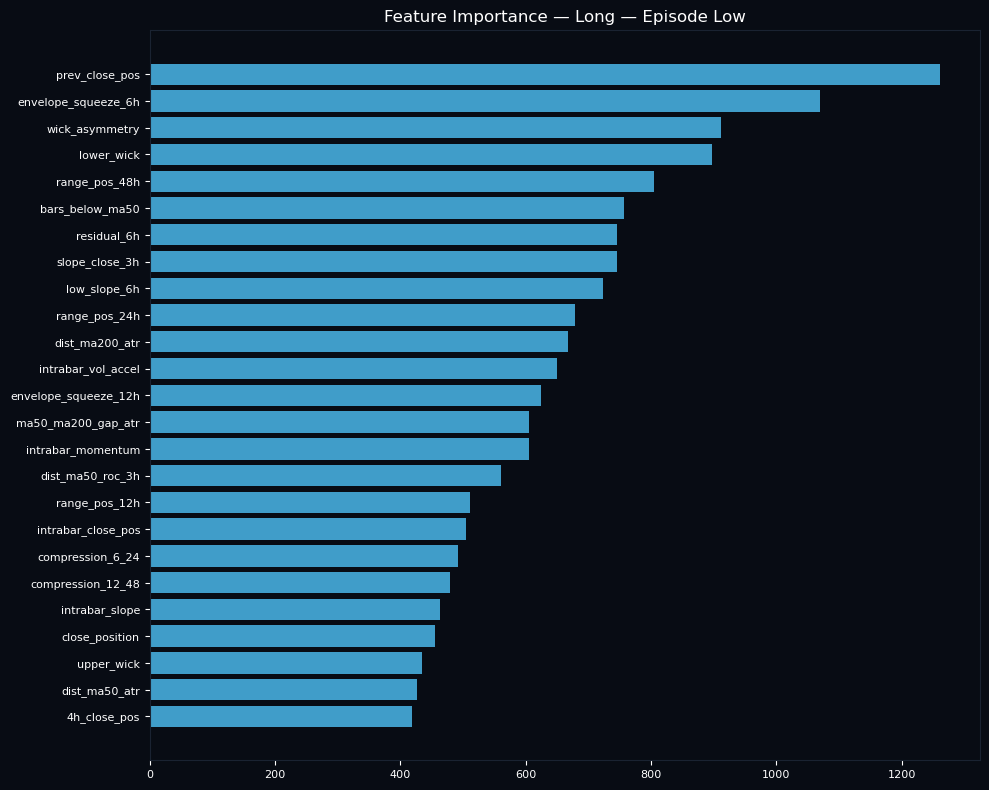

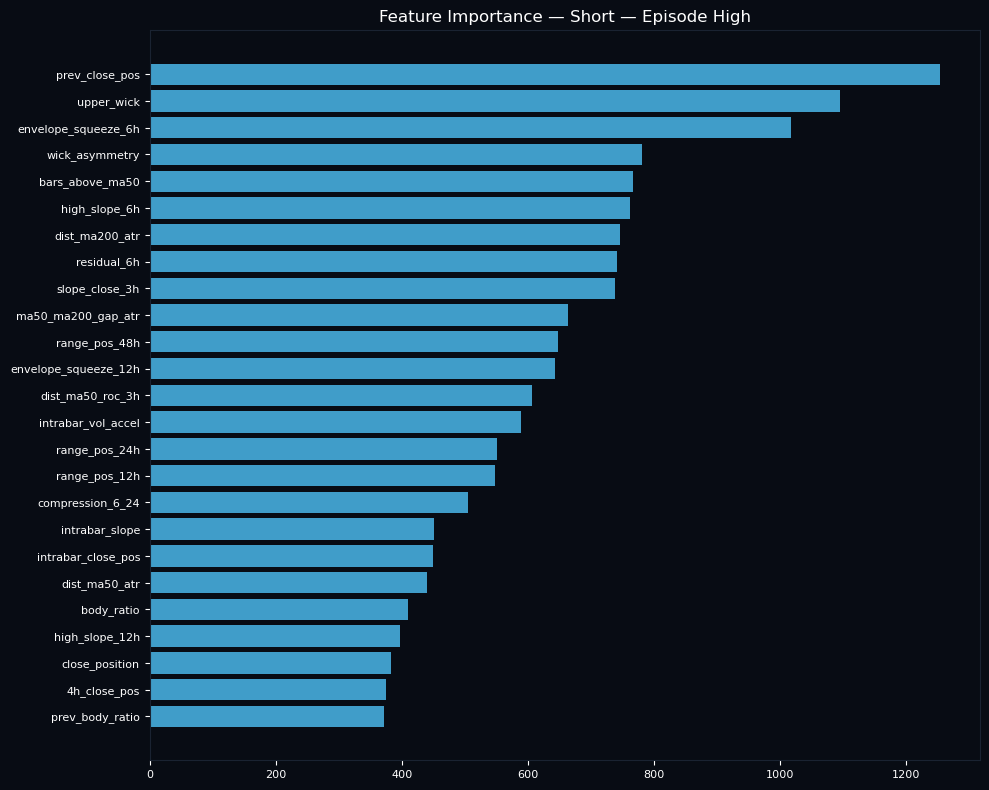

In [87]:
import matplotlib.pyplot as plt

for fname, label in [('model_ep_low.joblib', 'Long — Episode Low'), ('model_ep_high.joblib', 'Short — Episode High')]:
    bundle     = joblib.load(MODELS_DIR / fname)
    importance = pd.Series(bundle['model'].feature_importances_, index=feature_cols)
    importance = importance.sort_values(ascending=True).tail(25)
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor('#080c14'); ax.set_facecolor('#080c14')
    ax.barh(importance.index, importance.values, color='#4fc3f7', alpha=0.8)
    ax.tick_params(colors='white', labelsize=8)
    ax.set_title(f'Feature Importance — {label}', color='white', fontsize=12)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
    plt.tight_layout(); plt.show()


## 6. EV Simulation

For bars flagged as episode low (proba >= threshold): enter long at close, TP = first bar where price crosses above both MAs, timeout = close at T+120H, spread = 1.5p.

In [88]:
def ev_sim(results, direction):
    SPREAD_PIPS = 1.5
    sign = 1 if direction == 'long' else -1
    print(f'EV simulation ({direction.upper()}): TP=first close {"above" if direction=="long" else "below"} both MAs, timeout=T+120H')
    print(f'{"Thresh":>8} {"N":>7} {"WR":>7} {"Avg win":>9} {"Avg loss":>9} {"EV":>8} {"Sharpe":>8}')
    print('-' * 65)
    for t in [0.05, 0.1, 0.2, 0.3, 0.5]:
        mask = results['proba'] >= t
        if mask.sum() < 10: continue
        sigs = results[mask]
        pnls = []
        for pair in PAIRS:
            pip  = PIP_SIZE[pair]
            ohlc = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')[['close']]
            ohlc.index = pd.to_datetime(ohlc.index)
            c_arr   = ohlc['close'].values
            ma50_s  = pd.Series(c_arr).rolling(50).mean()
            ma200_s = pd.Series(c_arr).rolling(200).mean()
            filt = sigs[sigs['pair'] == pair]
            for ts, row in filt.iterrows():
                if ts not in ohlc.index: continue
                iloc  = ohlc.index.get_loc(ts)
                entry = ohlc['close'].iloc[iloc]
                pnl   = None
                for k in range(1, 121):
                    if iloc + k >= len(ohlc): break
                    c_k     = ohlc['close'].iloc[iloc+k]
                    ma50_k  = ma50_s.iloc[iloc+k]
                    ma200_k = ma200_s.iloc[iloc+k]
                    if pd.notna(ma50_k) and pd.notna(ma200_k):
                        if direction == 'long'  and c_k > ma50_k and c_k > ma200_k:
                            pnl = (c_k - entry) / pip - SPREAD_PIPS; break
                        elif direction == 'short' and c_k < ma50_k and c_k < ma200_k:
                            pnl = (entry - c_k) / pip - SPREAD_PIPS; break
                if pnl is None:
                    c_end = ohlc['close'].iloc[min(iloc+120, len(ohlc)-1)]
                    pnl   = sign * (c_end - entry) / pip - SPREAD_PIPS
                pnls.append(pnl)
        pnls   = np.array(pnls)
        wins   = pnls[pnls > 0]; losses = pnls[pnls <= 0]
        ev     = pnls.mean()
        sharpe = ev / pnls.std() * np.sqrt(252) if pnls.std() > 0 else 0
        print(f'{t:>8.2f} {len(pnls):>7,} {(pnls>0).mean():>7.1%} '
              f'{wins.mean() if len(wins) else 0:>9.1f} '
              f'{losses.mean() if len(losses) else 0:>9.1f} '
              f'{ev:>8.2f} {sharpe:>8.3f}')

ev_sim(results_long,  'long')
print()
ev_sim(results_short, 'short')


EV simulation (LONG): TP=first close above both MAs, timeout=T+120H
  Thresh       N      WR   Avg win  Avg loss       EV   Sharpe
-----------------------------------------------------------------
    0.05   3,242   74.8%      58.0     -67.5    26.37    5.160
    0.10   2,846   74.4%      57.1     -67.1    25.34    4.997
    0.20   2,441   74.6%      56.4     -65.3    25.46    5.084
    0.30   2,125   74.4%      55.2     -65.2    24.36    4.926
    0.50   1,519   75.4%      52.0     -63.9    23.56    5.002

EV simulation (SHORT): TP=first close below both MAs, timeout=T+120H
  Thresh       N      WR   Avg win  Avg loss       EV   Sharpe
-----------------------------------------------------------------
    0.05   4,774   61.3%      51.1     -89.9    -3.49   -0.611
    0.10   4,144   61.5%      50.3     -89.8    -3.56   -0.627
    0.20   3,423   61.9%      49.2     -90.8    -4.14   -0.734
    0.30   2,871   61.6%      48.1     -91.0    -5.36   -0.951
    0.50   1,922   62.1%      44.6   

## 7. Hour Distribution

In [89]:
for results, label in [(results_long, 'LONG'), (results_short, 'SHORT')]:
    sub = results[results['proba'] >= 0.2].copy()
    sub['hour'] = sub.index.hour
    by_hour = sub.groupby('hour').agg(n=('actual','count'), hit_rate=('actual','mean'))
    total = by_hour['n'].sum()
    print(f'Hour distribution ({label}, proba>=0.2), total={int(total):,}')
    print(f'{"Hour":>5} {"N":>6} {"%":>6} {"Hit%":>7}')
    print('-'*30)
    for hour, row in by_hour.iterrows():
        bar = '#' * int(row['n'] / total * 30)
        print(f'{hour:>5} {int(row["n"]):>6} {row["n"]/total:>6.1%} {row["hit_rate"]:>7.1%}  {bar}')
    print()


Hour distribution (LONG, proba>=0.2), total=2,441
 Hour      N      %    Hit%
------------------------------
    0     91   3.7%    4.4%  #
    1     85   3.5%   12.9%  #
    2     92   3.8%    5.4%  #
    3     91   3.7%    4.4%  #
    4     94   3.9%    3.2%  #
    5    104   4.3%    3.8%  #
    6    105   4.3%    5.7%  #
    7    114   4.7%   13.2%  #
    8    134   5.5%    8.2%  #
    9    118   4.8%    4.2%  #
   10    122   5.0%    4.9%  #
   11     94   3.9%    9.6%  #
   12    105   4.3%    9.5%  #
   13    123   5.0%   10.6%  #
   14    129   5.3%    8.5%  #
   15    146   6.0%   13.0%  #
   16    126   5.2%    3.2%  #
   17    110   4.5%    7.3%  #
   18     81   3.3%    4.9%  
   19     72   2.9%    0.0%  
   20     54   2.2%    5.6%  
   21     98   4.0%   15.3%  #
   22     94   3.9%   20.2%  #
   23     59   2.4%    1.7%  

Hour distribution (SHORT, proba>=0.2), total=3,423
 Hour      N      %    Hit%
------------------------------
    0    164   4.8%    4.9%  #
    1    

## 8. Per-Pair Breakdown

In [90]:
for results, label in [(results_long, 'LONG'), (results_short, 'SHORT')]:
    sub = results[results['proba'] >= 0.2]
    print(f'{label} per-pair (proba>=0.2):')
    print(f'{"Pair":>10} {"N":>6} {"Hit%":>7} {"AUC":>8}')
    print('-'*35)
    for pair, g in sub.groupby('pair'):
        if len(g) < 20 or g['actual'].nunique() < 2: continue
        print(f'{pair:>10} {len(g):>6,} {g["actual"].mean():>7.1%} {roc_auc_score(g["actual"], g["proba"]):>8.4f}')
    print()


LONG per-pair (proba>=0.2):
      Pair      N    Hit%      AUC
-----------------------------------
    AUDJPY    113    9.7%   0.8663
    AUDNZD    182    7.1%   0.7451
    AUDUSD    172    8.1%   0.6917
    CADJPY    115    8.7%   0.7390
    CHFJPY    134    7.5%   0.8258
    EURAUD    206    6.3%   0.8896
    EURGBP    220    9.1%   0.8105
    EURJPY    117   12.0%   0.7940
    EURUSD    161    6.2%   0.7311
    GBPJPY    118   11.9%   0.8125
    GBPUSD    141    7.8%   0.7734
    NZDUSD    202    7.4%   0.8528
    USDCAD    186    4.3%   0.6868
    USDCHF    222    5.4%   0.8123
    USDJPY    152    9.9%   0.8555

SHORT per-pair (proba>=0.2):
      Pair      N    Hit%      AUC
-----------------------------------
    AUDJPY    300    4.3%   0.8022
    AUDNZD    252    7.5%   0.7856
    AUDUSD    229    5.2%   0.7715
    CADJPY    254    4.7%   0.7586
    CHFJPY    274    4.4%   0.6899
    EURAUD    147    8.2%   0.8370
    EURGBP    217    7.8%   0.7950
    EURJPY    323    4.3%   0.

## 9. Entry Quality — How Close to Actual Low/High?

In [91]:
for results, label, direction in [(results_long, 'LONG', 'long'), (results_short, 'SHORT', 'short')]:
    r2 = results.copy()
    r2['gap']   = r2.index.to_series().diff().dt.total_seconds() > 7200
    r2['ep_id'] = r2['gap'].cumsum()
    early, late, bars_diffs, slippages = 0, 0, [], []
    for pair in PAIRS:
        pip  = PIP_SIZE[pair]
        ohlc = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')[['close','high','low']]
        ohlc.index = pd.to_datetime(ohlc.index)
        pr = r2[r2['pair'] == pair]
        for ep_id, ep in pr.groupby('ep_id'):
            entry_ts  = ep['proba'].idxmax()
            actual_ep = ep[ep['actual'] == 1]
            if len(actual_ep) == 0: continue
            actual_ts = actual_ep.index[0]
            if entry_ts not in ohlc.index or actual_ts not in ohlc.index: continue
            ep_price  = ohlc['close'].loc[entry_ts]
            act_price = ohlc['low'].loc[actual_ts] if direction == 'long' else ohlc['high'].loc[actual_ts]
            bars_diff = (entry_ts - actual_ts).total_seconds() / 3600
            slippage  = (ep_price - act_price) / pip if direction == 'long' else (act_price - ep_price) / pip
            bars_diffs.append(bars_diff); slippages.append(slippage)
            if bars_diff < 0: early += 1
            else: late += 1
    total = early + late
    print(f'{label} entry quality ({total} episodes):')
    print(f'  Entered before actual extreme: {early} ({early/total:.1%})')
    print(f'  Entered after  actual extreme: {late}  ({late/total:.1%})')
    print(f'  Bars diff  — mean={np.mean(bars_diffs):.1f}H  median={np.median(bars_diffs):.1f}H')
    print(f'  Slippage   — mean={np.mean(slippages):.1f}p   median={np.median(slippages):.1f}p')
    print()


LONG entry quality (129 episodes):
  Entered before actual extreme: 51 (39.5%)
  Entered after  actual extreme: 78  (60.5%)
  Bars diff  — mean=-0.1H  median=0.0H
  Slippage   — mean=53.3p   median=29.0p

SHORT entry quality (134 episodes):
  Entered before actual extreme: 62 (46.3%)
  Entered after  actual extreme: 72  (53.7%)
  Bars diff  — mean=-1.9H  median=0.0H
  Slippage   — mean=44.8p   median=28.3p



In [92]:
# Baseline: no model, just first bar of each short episode
baseline_pnls = []
for pair in PAIRS:
    pip  = PIP_SIZE[pair]
    ohlc = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')[['close']]
    ohlc.index = pd.to_datetime(ohlc.index)
    c_arr   = ohlc['close'].values
    ma50_s  = pd.Series(c_arr).rolling(50).mean()
    ma200_s = pd.Series(c_arr).rolling(200).mean()
    both_above = (pd.Series(c_arr) > ma50_s) & (pd.Series(c_arr) > ma200_s)

    in_ep = False
    for i in range(len(c_arr)):
        if both_above.iloc[i] and not in_ep:
            in_ep = True
            entry = c_arr[i]
            pnl = None
            for k in range(1, 121):
                if i + k >= len(c_arr): break
                c_k = ohlc['close'].iloc[i+k]
                if pd.notna(ma50_s.iloc[i+k]) and c_k < ma50_s.iloc[i+k] and c_k < ma200_s.iloc[i+k]:
                    pnl = (entry - c_k) / pip - 1.5; break
            if pnl is None:
                pnl = (entry - c_arr[min(i+120, len(c_arr)-1)]) / pip - 1.5
            baseline_pnls.append(pnl)
        elif not both_above.iloc[i]:
            in_ep = False

baseline = np.array(baseline_pnls)
print(f'Baseline SHORT (no model, first bar of episode):')
print(f'N={len(baseline):,}  WR={(baseline>0).mean():.1%}  avg_win={baseline[baseline>0].mean():.1f}p  avg_loss={baseline[baseline<=0].mean():.1f}p  EV={baseline.mean():.2f}p')


Baseline SHORT (no model, first bar of episode):
N=39,791  WR=75.1%  avg_win=46.8p  avg_loss=-119.0p  EV=5.46p


In [93]:
# Deduped EV: one trade per episode (highest proba bar), both directions
for results, label, direction in [(results_long, 'LONG', 'long'), (results_short, 'SHORT', 'short')]:
    r2 = results.copy()
    r2['gap']   = r2.index.to_series().diff().dt.total_seconds() > 7200
    r2['ep_id'] = r2['gap'].cumsum()

    pnls = []
    for pair in PAIRS:
        pip  = PIP_SIZE[pair]
        ohlc = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')[['close']]
        ohlc.index = pd.to_datetime(ohlc.index)
        ma50_s  = pd.Series(ohlc['close'].values).rolling(50).mean()
        ma200_s = pd.Series(ohlc['close'].values).rolling(200).mean()

        pr = r2[r2['pair'] == pair]
        for ep_id, ep in pr.groupby('ep_id'):
            ts    = ep['proba'].idxmax()
            if ts not in ohlc.index: continue
            iloc  = ohlc.index.get_loc(ts)
            entry = ohlc['close'].iloc[iloc]
            pnl   = None
            for k in range(1, 121):
                if iloc + k >= len(ohlc): break
                c_k = ohlc['close'].iloc[iloc+k]
                m50 = ma50_s.iloc[iloc+k]; m200 = ma200_s.iloc[iloc+k]
                if pd.notna(m50) and pd.notna(m200):
                    if direction == 'long'  and c_k > m50 and c_k > m200:
                        pnl = (c_k - entry) / pip - 1.5; break
                    elif direction == 'short' and c_k < m50 and c_k < m200:
                        pnl = (entry - c_k) / pip - 1.5; break
            if pnl is None:
                c_end = ohlc['close'].iloc[min(iloc+120, len(ohlc)-1)]
                pnl = ((c_end - entry) if direction == 'long' else (entry - c_end)) / pip - 1.5
            pnls.append(pnl)

    pnls = np.array(pnls)
    wins = pnls[pnls > 0]; losses = pnls[pnls <= 0]
    print(f'{label} deduped: N={len(pnls):,}  WR={(pnls>0).mean():.1%}  '
          f'avg_win={wins.mean():.1f}p  avg_loss={losses.mean():.1f}p  EV={pnls.mean():.2f}p')


LONG deduped: N=187  WR=79.7%  avg_win=47.1p  avg_loss=-67.5p  EV=23.79p
SHORT deduped: N=198  WR=68.7%  avg_win=42.9p  avg_loss=-84.3p  EV=3.09p


In [94]:
for results, label, direction in [(results_long, 'LONG', 'long'), (results_short, 'SHORT', 'short')]:
    r2 = results.copy()
    r2['gap']   = r2.index.to_series().diff().dt.total_seconds() > 7200
    r2['ep_id'] = r2['gap'].cumsum()

    hold_times, never_hit = [], 0
    for pair in PAIRS:
        pip  = PIP_SIZE[pair]
        ohlc = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')[['close']]
        ohlc.index = pd.to_datetime(ohlc.index)
        c_arr   = ohlc['close'].values
        ma200_s = pd.Series(c_arr).rolling(200).mean()

        pr = r2[r2['pair'] == pair]
        for ep_id, ep in pr.groupby('ep_id'):
            ts   = ep['proba'].idxmax()
            if ts not in ohlc.index: continue
            iloc = ohlc.index.get_loc(ts)
            entry = c_arr[iloc]
            hit_bar = None
            for k in range(1, len(c_arr) - iloc):
                c_k  = c_arr[iloc + k]
                m200 = ma200_s.iloc[iloc + k]
                if pd.isna(m200): continue
                if direction == 'long'  and c_k > m200:
                    hit_bar = k; break
                elif direction == 'short' and c_k < m200:
                    hit_bar = k; break
            if hit_bar is None:
                never_hit += 1; continue
            pnl = ((c_arr[iloc+hit_bar] - entry) if direction == 'long' else (entry - c_arr[iloc+hit_bar])) / pip - 1.5
            hold_times.append({'bars': hit_bar, 'pnl': pnl, 'win': pnl > 0})

    df_h = pd.DataFrame(hold_times)
    print(f'{label} hold period (N={len(df_h):,}, never_hit={never_hit}):')
    print(f'  Mean:   {df_h["bars"].mean():.1f}H')
    print(f'  Median: {df_h["bars"].median():.0f}H')
    print(f'  P25:    {df_h["bars"].quantile(0.25):.0f}H')
    print(f'  P75:    {df_h["bars"].quantile(0.75):.0f}H')
    print(f'  P90:    {df_h["bars"].quantile(0.90):.0f}H')
    print(f'  Max:    {df_h["bars"].max():.0f}H')
    print()
    print(f'  Winners  — mean={df_h[df_h["win"]]["bars"].mean():.1f}H  median={df_h[df_h["win"]]["bars"].median():.0f}H')
    print(f'  Losers   — mean={df_h[~df_h["win"]]["bars"].mean():.1f}H  median={df_h[~df_h["win"]]["bars"].median():.0f}H')
    print()
    print(f'  Buckets:')
    for lo, hi in [(1,12),(12,24),(24,48),(48,72),(72,120),(120,240),(240,99999)]:
        n = ((df_h['bars']>=lo)&(df_h['bars']<hi)).sum()
        print(f'    {lo:>4}-{hi:>4}H: {n:>5,} ({n/len(df_h):.1%})')
    print()


LONG hold period (N=179, never_hit=8):
  Mean:   55.6H
  Median: 28H
  P25:    2H
  P75:    84H
  P90:    151H
  Max:    355H

  Winners  — mean=34.1H  median=14H
  Losers   — mean=176.7H  median=163H

  Buckets:
       1-  12H:    73 (40.8%)
      12-  24H:    13 (7.3%)
      24-  48H:    21 (11.7%)
      48-  72H:    16 (8.9%)
      72- 120H:    28 (15.6%)
     120- 240H:    23 (12.8%)
     240-99999H:     5 (2.8%)

SHORT hold period (N=183, never_hit=15):
  Mean:   75.7H
  Median: 53H
  P25:    7H
  P75:    114H
  P90:    197H
  Max:    354H

  Winners  — mean=42.7H  median=26H
  Losers   — mean=183.1H  median=175H

  Buckets:
       1-  12H:    56 (30.6%)
      12-  24H:    13 (7.1%)
      24-  48H:    19 (10.4%)
      48-  72H:    24 (13.1%)
      72- 120H:    26 (14.2%)
     120- 240H:    36 (19.7%)
     240-99999H:     9 (4.9%)



In [95]:
for results, label, direction in [(results_long, 'LONG', 'long'), (results_short, 'SHORT', 'short')]:
    r2 = results.copy()
    r2['gap']   = r2.index.to_series().diff().dt.total_seconds() > 7200
    r2['ep_id'] = r2['gap'].cumsum()

    print(f'{label} — timeout sensitivity (entry: first bar >= 0.2 in episode):')
    print(f'{"Timeout":>10} {"N":>6} {"WR":>7} {"Avg win":>9} {"Avg loss":>9} {"EV":>8}')
    print('-'*55)

    for timeout in [24, 48, 72, 120, 240, 99999]:
        pnls = []
        for pair in PAIRS:
            pip  = PIP_SIZE[pair]
            ohlc = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')[['close']]
            ohlc.index = pd.to_datetime(ohlc.index)
            c_arr   = ohlc['close'].values
            ma200_s = pd.Series(c_arr).rolling(200).mean()

            pr = r2[r2['pair'] == pair]
            for ep_id, ep in pr.groupby('ep_id'):
                # First bar in episode with proba >= threshold
                above = ep[ep['proba'] >= 0.2]
                if len(above) == 0:
                    continue
                ts = above.index[0]
                if ts not in ohlc.index: continue
                iloc  = ohlc.index.get_loc(ts)
                entry = c_arr[iloc]
                pnl   = None
                for k in range(1, min(timeout+1, len(c_arr)-iloc)):
                    c_k  = c_arr[iloc+k]
                    m200 = ma200_s.iloc[iloc+k]
                    if pd.isna(m200): continue
                    if direction == 'long'  and c_k > m200:
                        pnl = (c_k - entry) / pip - 1.5; break
                    elif direction == 'short' and c_k < m200:
                        pnl = (entry - c_k) / pip - 1.5; break
                if pnl is None:
                    c_end = c_arr[min(iloc+timeout, len(c_arr)-1)]
                    pnl = ((c_end - entry) if direction == 'long' else (entry - c_end)) / pip - 1.5
                pnls.append(pnl)

        pnls = np.array(pnls)
        wins = pnls[pnls > 0]; losses = pnls[pnls <= 0]
        lbl  = f'{timeout}H' if timeout < 99999 else 'none'
        print(f'{lbl:>10} {len(pnls):>6,} {(pnls>0).mean():>7.1%} '
              f'{wins.mean() if len(wins) else 0:>9.1f} '
              f'{losses.mean() if len(losses) else 0:>9.1f} '
              f'{pnls.mean():>8.2f}')
    print()


LONG — timeout sensitivity (entry: first bar >= 0.2 in episode):
   Timeout      N      WR   Avg win  Avg loss       EV
-------------------------------------------------------
       24H    169   65.7%      16.7     -37.6    -1.92
       48H    169   72.2%      20.7     -57.5    -1.07
       72H    169   74.6%      21.9     -65.6    -0.36
      120H    169   84.6%      27.0     -83.1    10.06
      240H    169   85.8%      27.3     -79.8    12.06
      none    169   85.8%      27.3     -72.8    13.05

SHORT — timeout sensitivity (entry: first bar >= 0.2 in episode):
   Timeout      N      WR   Avg win  Avg loss       EV
-------------------------------------------------------
       24H    187   59.4%      23.8     -40.1    -2.21
       48H    187   64.7%      27.6     -71.5    -7.35
       72H    187   64.7%      29.4     -96.3   -14.95
      120H    187   68.4%      30.2     -80.7    -4.79
      240H    187   71.1%      30.5     -72.5     0.77
      none    187   71.1%      30.5     -